# 02b · Structural features from FastSurfer segmentation (protocol §3.2, D5)

The raw COBRE T1 scans arrived (148 participants, one 3-D volume each at 1 mm, with the five MPRAGE echoes already combined). This notebook turns them into the structural feature block $X_s$.

## Why FastSurfer segmentation rather than FreeSurfer surfaces

The protocol's original plan (D5) was FreeSurfer's Desikan–Killiany atlas: cortical **thickness**, **surface area** and subcortical volumes. Producing thickness and area requires reconstructing the cortical surfaces, which takes roughly 6–10 hours per participant with FreeSurfer, or about an hour with FastSurfer's surface module. For 146 participants that is days of compute, and it needs FreeSurfer binaries that do not run natively on Windows.

**What we do instead:** FastSurfer's deep-learning segmentation (`--seg_only`), which is pure PyTorch, runs on the local GPU in about a minute per participant, and needs no FreeSurfer installation. It labels the whole brain using the **DKT atlas**, so every region gets a **volume**.

| | Original D5 | This notebook |
|---|---|---|
| Pipeline | FreeSurfer `recon-all` | FastSurfer VINN segmentation (`--seg_only`) |
| Atlas | Desikan–Killiany (34 regions/hemisphere) | DKT (31 regions/hemisphere) |
| Measures | thickness + surface area + subcortical volume | **regional volume only** |
| Compute | ≈ 6–10 h per participant | ≈ 1 min per participant on GPU |

**What this costs.** Cortical thinning is the most replicated structural finding in schizophrenia, and volume mixes thickness with surface area, so it is a blunter instrument. This is a real loss of sensitivity, recorded as a deviation in protocol §13 with "compute constraints" as the stated reason, and decided before any structural result was seen.

**Head-size adjustment.** Without surfaces there is no FreeSurfer eTIV, so each regional volume is divided by that participant's **total segmented brain volume**. Like the eTIV ratio it uses only the participant's own data, so it cannot leak across folds.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
NOTEBOOKS = ROOT / "notebooks"
FASTSURFER_OUT = Path(r"C:\Users\diksh\cobre_fastsurfer")       # kept outside OneDrive
# The full FreeSurfer table, not FastSurfer's own FastSurfer_ColorLUT.tsv: that one maps
# only the left-hemisphere cortical labels, leaving every 2000-series right-hemisphere
# region unnamed.
LUT_PATH = Path(r"C:\Users\diksh\OneDrive\Desktop\mri\FastSurfer\FastSurferCNN\config\FreeSurferColorLUT.txt")
SEG_NAME = "aparc.DKTatlas+aseg.deep.mgz"

# The 14 subcortical structures named in protocol §3.2.
SUBCORTICAL = [
    "Left-Thalamus", "Left-Caudate", "Left-Putamen", "Left-Pallidum", "Left-Hippocampus",
    "Left-Amygdala", "Left-Accumbens-area",
    "Right-Thalamus", "Right-Caudate", "Right-Putamen", "Right-Pallidum", "Right-Hippocampus",
    "Right-Amygdala", "Right-Accumbens-area",
]
# Labels that describe tissue compartments rather than anatomy: used for the head-size
# denominator, never as features.
NON_FEATURE = ("Background", "Unknown", "CSF", "WM-hypointensities")


def use_notebook(name):
    """Run the definition cells (tagged "library") of another notebook in this namespace."""
    notebook = json.loads((NOTEBOOKS / name).read_text(encoding="utf-8"))
    for cell in notebook["cells"]:
        if cell["cell_type"] == "code" and "library" in cell["metadata"].get("tags", []):
            exec("".join(cell["source"]), globals())


def load_yaml(path):
    with open(path, encoding="utf-8") as fh:
        return yaml.safe_load(fh)

In [2]:
import nibabel as nib


def load_lut(path=LUT_PATH):
    """{label id: region name} from the FreeSurfer colour lookup table.

    Format is whitespace-separated: id, name, R, G, B, A, with '#' comments.
    """
    lut = {}
    for line in Path(path).read_text(encoding="utf-8", errors="ignore").splitlines():
        parts = line.split()
        if len(parts) >= 2 and parts[0].isdigit():
            lut[int(parts[0])] = parts[1]
    return lut


def segmentation_volumes(segmentation_path, lut):
    """{region name: volume in mm3} for one participant's segmentation."""
    image = nib.load(str(segmentation_path))
    data = np.asarray(image.dataobj)
    voxel_mm3 = float(np.prod(image.header.get_zooms()[:3]))
    ids, counts = np.unique(data, return_counts=True)
    return {lut.get(int(i), f"label_{int(i)}"): int(c) * voxel_mm3 for i, c in zip(ids, counts) if int(i) != 0}


def structural_feature_table(seg_dir=FASTSURFER_OUT, lut=None):
    """Volume table for every segmented participant, plus the head-size denominator.

    Features are the DKT cortical regions (ctx-*) and the 14 subcortical structures,
    each divided by that participant's total segmented brain volume.
    """
    lut = lut or load_lut()
    rows, quality = [], []
    for subject in sorted(p for p in seg_dir.iterdir() if (p / "mri" / SEG_NAME).exists()):
        volumes = segmentation_volumes(subject / "mri" / SEG_NAME, lut)
        total = sum(v for name, v in volumes.items() if not name.startswith(NON_FEATURE))
        features = {f"vol_{name}": volumes.get(name, 0.0) / total
                    for name in sorted(volumes) if name.startswith("ctx-") or name in SUBCORTICAL}
        rows.append({"participant_id": subject.name, **features})
        quality.append({"participant_id": subject.name, "total_brain_volume_mm3": total,
                        "n_labels": len(volumes)})
    features = pd.DataFrame(rows)
    return features, pd.DataFrame(quality)

## Build the feature table
Reads every segmentation produced by the batch run, converts voxel counts to volumes using each image's voxel size, and divides by the participant's total segmented brain volume.

In [3]:
lut = load_lut()
print(f"lookup table: {len(lut)} labels")
features, quality = structural_feature_table(lut=lut)
feature_columns = [c for c in features.columns if c != "participant_id"]
cortical = [c for c in feature_columns if "ctx-" in c]
subcortical = [c for c in feature_columns if "ctx-" not in c]
print(f"{len(features)} participants x {len(feature_columns)} features "
      f"({len(cortical)} cortical DKT regions + {len(subcortical)} subcortical structures)")
display(features.iloc[:3, :6])
display(quality.describe().round(1))

lookup table: 1791 labels


146 participants x 76 features (62 cortical DKT regions + 14 subcortical structures)


,participant_id,vol_Left-Accumbens-area,vol_Left-Amygdala,vol_Left-Caudate,vol_Left-Hippocampus,vol_Left-Pallidum
0,sub-0040000,0.000483,0.001376,0.003370,0.003720,0.002098
1,sub-0040001,0.000435,0.001721,0.003326,0.003612,0.002341
2,sub-0040002,0.000480,0.001208,0.003304,0.003243,0.002080


,total_brain_volume_mm3,n_labels
count,146.0,146.0
mean,1190946.0,95.0
std,130753.1,0.0
min,851943.0,95.0
25%,1104758.5,95.0
50%,1183327.5,95.0
75%,1257522.0,95.0
max,1583103.0,95.0


## Quality checks
- every participant has the same label set, so no segmentation failed silently;
- no feature is zero or missing;
- total brain volume falls in a plausible human range (roughly 1.0–1.8 litres);
- volumes relate to head size sensibly before normalization.

features with any zero volume: 0
total brain volume (litres): min 0.85, median 1.18, max 1.58
label counts identical across participants: True


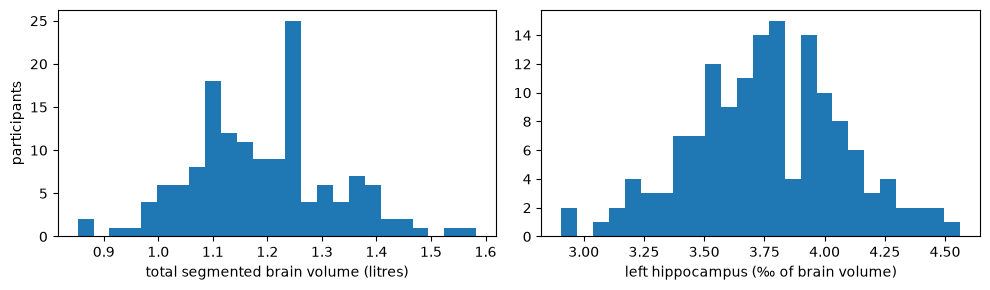

In [4]:
values = features[feature_columns].to_numpy(float)
assert np.isfinite(values).all(), "non-finite volumes"
print("features with any zero volume:", int((values == 0).any(axis=0).sum()))
print("total brain volume (litres): min {:.2f}, median {:.2f}, max {:.2f}".format(
    quality["total_brain_volume_mm3"].min() / 1e6, quality["total_brain_volume_mm3"].median() / 1e6,
    quality["total_brain_volume_mm3"].max() / 1e6))
print("label counts identical across participants:", quality["n_labels"].nunique() == 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(quality["total_brain_volume_mm3"] / 1e6, bins=25)
axes[0].set(xlabel="total segmented brain volume (litres)", ylabel="participants")
axes[1].hist(features["vol_Left-Hippocampus"] * 1000, bins=25)
axes[1].set(xlabel="left hippocampus (‰ of brain volume)")
plt.tight_layout()
plt.show()

## Save
Written next to the functional features so notebook 10 can join them by participant.

In [5]:
cfg = load_yaml(ROOT / "configs" / "data_config.yaml")
out = ROOT / cfg["features_dir"]
out.mkdir(parents=True, exist_ok=True)
features.to_csv(out / "structural_features_fastsurfer.csv", index=False, float_format="%.8g")
quality.to_csv(out / "structural_qc_fastsurfer.csv", index=False)
print("written:", (out / "structural_features_fastsurfer.csv").relative_to(ROOT))
print("feature count reported in the paper:", len(feature_columns))

written: data\derivatives\features\structural_features_fastsurfer.csv
feature count reported in the paper: 76
